In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("C:/WORK/PROJECTS/HOME-CREDIT-RISK-AUTOMATION/data/clean/home_credit_360.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 63 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   sk_id_curr                   307511 non-null  int64  
 1   target                       307511 non-null  int64  
 2   CNT_CHILDREN                 307511 non-null  int64  
 3   CNT_FAM_MEMBERS              307509 non-null  float64
 4   CODE_GENDER                  307511 non-null  object 
 5   NAME_FAMILY_STATUS           307511 non-null  object 
 6   NAME_EDUCATION_TYPE          307511 non-null  object 
 7   NAME_INCOME_TYPE             307511 non-null  object 
 8   AMT_INCOME_TOTAL             307511 non-null  float64
 9   AMT_CREDIT                   307511 non-null  float64
 10  AMT_ANNUITY                  307499 non-null  float64
 11  AMT_GOODS_PRICE              307233 non-null  float64
 12  DAYS_BIRTH                   307511 non-null  int64  
 13 

In [ ]:
df.isnull().sum()

sk_id_curr                       0
target                           0
CNT_CHILDREN                     0
CNT_FAM_MEMBERS                  2
CODE_GENDER                      0
                             ...  
income_credit_ratio              0
annuity_income_ratio            12
bureau_debt_credit_ratio     52357
late_payment_ratio           18105
credit_utilization_ratio    230450
Length: 63, dtype: int64

# NULL HANDLING

## EXT SOURCE NULL HANDLING

In [ ]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["ext_source_avg"] = df[ext_cols].mean(axis=1, skipna=True)
df["ext_source_missing_flag"] = df[ext_cols].isnull().all(axis=1).astype(int)

EXT SOURCES(1,2,3) ARE IMPORTANT COLUMNS SO WE HAVE CREATED AN AGGREATED COLUMN SHOWING US THW AVG EXTERNAL CREDIT ALONG WITH EXT SOURCE MISSING COLUMNS WHICH SHOWS THAT EXTERNAL CREDIT DATA IS FOR THIS USER IS MISSING (NOT 0)

## BEREAUE HISTORY NULL

In [ ]:
count_cols = [
    "bureau_total_loans",
    "bureau_active_loans",
    "bureau_closed_loans"
]

df[count_cols] = df[count_cols].fillna(0).astype(int)

In [ ]:
numeric_cols = [
    "bureau_total_debt_sum",
    "bureau_total_overdue_sum",
    "bureau_avg_days_credit",
    "bureau_max_days_credit",
    "bureau_avg_overdue_days",
    "bureau_max_overdue_days"
]

df[numeric_cols] = df[numeric_cols].fillna(0)

WE FILLED THESE COLUMNS WITH 0 INDICATING THAT THERE ARE USERS WHO HAVE NO DATA IN BEREAU DATASET 
MEANING THAT THEY DONT HAVE PAST RECORDS AND ARE 1ST TIME CUSTOMERS WHICH CAN A  GOOD RISK SIGNAL


THERE WE CREATE A NEW COLUMNS SHOWING WHETHER THEY ARE NEW TO CREDIT OR NOT

In [ ]:
df["no_credit_history_flag"] = (df["bureau_total_loans"] == 0).astype(int)

## CREDIT CARD DETAILS NULL


In [ ]:
credit_cols = [
    "credit_card_count",
    "avg_credit_card_balance",
    "max_credit_card_balance",
    "avg_credit_limit",
    "avg_credit_utilization",
    "max_credit_utilization",
    "avg_atm_withdrawal",
    "avg_monthly_payment",
    "avg_drawings_count"
]

df[credit_cols] = df[credit_cols].fillna(0)

FILLING MISSING COLUMNS WITH 0 as THEY HAVE NO PREVIOUS CREDIT CARD HISTORY

In [ ]:
df["credit_card_count"] = df["credit_card_count"].astype(int)

In [ ]:
df["has_credit_card"] = (df["credit_card_count"] > 0).astype(int)


creating a flag for users who have no credit card,it is to be observed that some people have had credit cards but do not use it while some people may be getting their 1st ever credit card both are diffrent risk indicators

In [ ]:
df["credit_experience"] = df["bureau_total_loans"] + df["credit_card_count"]

creating credit_experience score which monitors how many loans the person has taken along with their total credit cards

## PAYMENT INSTALLMENTS NULL HANDLING 

In [ ]:
installment_cols = [
    "total_installments",
    "avg_installment_amount",
    "avg_payment_amount",
    "late_payment_count",
    "on_time_payment_count",
    "avg_payment_delay",
    "max_payment_delay",
    "total_payment_amount"
]

df[installment_cols] = df[installment_cols].fillna(0)

In [ ]:
installment_cols = [
    "total_installments",
    "avg_installment_amount",
    "avg_payment_amount",
    "late_payment_count",
    "on_time_payment_count",
    "avg_payment_delay",
    "max_payment_delay",
    "total_payment_amount"
]

df[installment_cols] = df[installment_cols].fillna(0)   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 68 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   sk_id_curr                   307511 non-null  int64  
 1   target                       307511 non-null  int64  
 2   CNT_CHILDREN                 307511 non-null  int64  
 3   CNT_FAM_MEMBERS              307509 non-null  float64
 4   CODE_GENDER                  307511 non-null  object 
 5   NAME_FAMILY_STATUS           307511 non-null  object 
 6   NAME_EDUCATION_TYPE          307511 non-null  object 
 7   NAME_INCOME_TYPE             307511 non-null  object 
 8   AMT_INCOME_TOTAL             307511 non-null  float64
 9   AMT_CREDIT                   307511 non-null  float64
 10  AMT_ANNUITY                  307499 non-null  float64
 11  AMT_GOODS_PRICE              307233 non-null  float64
 12  DAYS_BIRTH                   307511 non-null  int64  
 13 

## POS COLUMNS

In [ ]:
pos_cols = [
"pos_cash_loan_count",
"avg_dpd",
"max_dpd",
"avg_dpd_def",
"max_dpd_def",
"pos_overdue_count"
]

df[pos_cols] = df[pos_cols].fillna(0)

In [ ]:
df["bureau_total_credit_sum"] = df["bureau_total_credit_sum"].fillna(0)
df["late_payment_ratio"] = df["late_payment_ratio"].fillna(0)
df["credit_utilization_ratio"] = df["credit_utilization_ratio"].fillna(0)


In [ ]:
#df = pd.get_dummies(df, columns=[
#"CODE_GENDER",
#"NAME_FAMILY_STATUS",
#"NAME_EDUCATION_TYPE",
#"NAME_INCOME_TYPE"
#], drop_first=True)

In [ ]:
df.drop("avg_prev_interest_rate", axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 67 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   sk_id_curr                   307511 non-null  int64  
 1   target                       307511 non-null  int64  
 2   CNT_CHILDREN                 307511 non-null  int64  
 3   CNT_FAM_MEMBERS              307509 non-null  float64
 4   CODE_GENDER                  307511 non-null  object 
 5   NAME_FAMILY_STATUS           307511 non-null  object 
 6   NAME_EDUCATION_TYPE          307511 non-null  object 
 7   NAME_INCOME_TYPE             307511 non-null  object 
 8   AMT_INCOME_TOTAL             307511 non-null  float64
 9   AMT_CREDIT                   307511 non-null  float64
 10  AMT_ANNUITY                  307499 non-null  float64
 11  AMT_GOODS_PRICE              307233 non-null  float64
 12  DAYS_BIRTH                   307511 non-null  int64  
 13 

## OUTLIER DETECTION

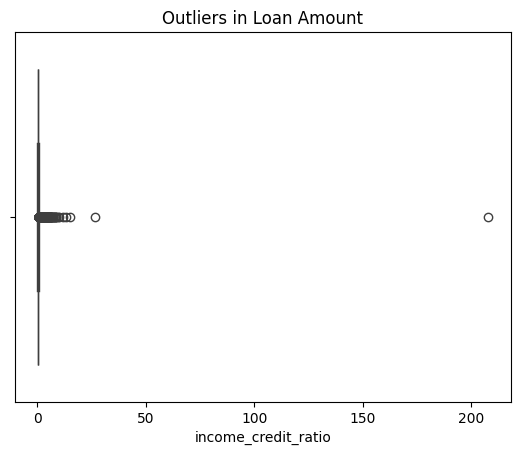

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["income_credit_ratio"])
plt.title("Outliers in Loan Amount")
plt.show()

## WHAT HAVE WE ACCOMPLISHED
At this step we have succesfully created a pipeline that 
1. Downloads the data from the cloud source
2. Integrates our data into a sql server
3. Creates an Aggregated Dataset
4. Cleaned the data of any Null Values and explained why those Null values occur in the first place

## WHAT WE ARE GOING TO DO 
1. Identify the major factors resulting in default
2. create a machine learning pipeline that ranks current customer who have not defaulted and gives them a score from 1-10 10 being the highest on how likely they are going to default

# FINDING MAJOR FACTORS LEADING TO DEFUALT

## DEMOGRAPHIC COLUMNS 

In [ ]:
demographic_cols = [
"CNT_CHILDREN",
"CNT_FAM_MEMBERS",
"DAYS_BIRTH",
"DAYS_EMPLOYED",
"DAYS_REGISTRATION",
"DAYS_ID_PUBLISH",
"CODE_GENDER",
'NAME_INCOME_TYPE',
"NAME_FAMILY_STATUS",
"NAME_EDUCATION_TYPE"
]
df_demographic = df[demographic_cols + ["target"]]

In [ ]:
df_demographic.groupby("CNT_CHILDREN")["target"].agg(["count","mean"])

,count,mean
CNT_CHILDREN,,
0,215371,0.077118
1,61119,0.089236
2,26749,0.087218
3,3717,0.096314
4,429,0.128205
5,84,0.083333
6,21,0.285714
7,7,0.000000
8,2,0.000000


In [ ]:
df_demographic.loc[:, "children_group"] = df_demographic["CNT_CHILDREN"].apply(
    lambda x: "0 children" if x == 0
    else "1-2 children" if x <= 2
    else "3+ children"
)

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\2052938199.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demographic.loc[:, "children_group"] = df_demographic["CNT_CHILDREN"].apply(


In [ ]:
df_demographic.groupby("children_group")["target"].agg(["count","mean"])

,count,mean
children_group,,
0 children,215371,0.077118
1-2 children,87868,0.088622
3+ children,4272,0.100421


people with 0 children have a slightly lower default rate compared to those with 1-2 children

In [ ]:

df_demographic.groupby("CNT_FAM_MEMBERS")["target"].agg(["count","mean"])

,count,mean
CNT_FAM_MEMBERS,,
1.0,67847,0.083644
2.0,158357,0.075835
3.0,52601,0.087603
4.0,24697,0.086488
5.0,3478,0.094020
6.0,408,0.134804
7.0,81,0.074074
8.0,20,0.300000
9.0,6,0.000000


In [ ]:
df_demographic.loc[:, "Family_Member_group"] = df_demographic["CNT_FAM_MEMBERS"].apply(
    lambda x: "1 Member" if x == 1
    else "2-4 Members" if x >1 and x<=4 
    else "5 and + Members"
)

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\1304481559.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demographic.loc[:, "Family_Member_group"] = df_demographic["CNT_FAM_MEMBERS"].apply(


In [ ]:

df_demographic.groupby("Family_Member_group")["target"].agg(["count","mean"])

,count,mean
Family_Member_group,,
1 Member,67847,0.083644
2-4 Members,235655,0.079578
5 and + Members,4009,0.099027


default rate of single member families is slightly more compared to that of 2-4 members 
interestingly default rate of families having 5 or more members have a higher default rate (close to 0.1) while having pretty low count in sample size

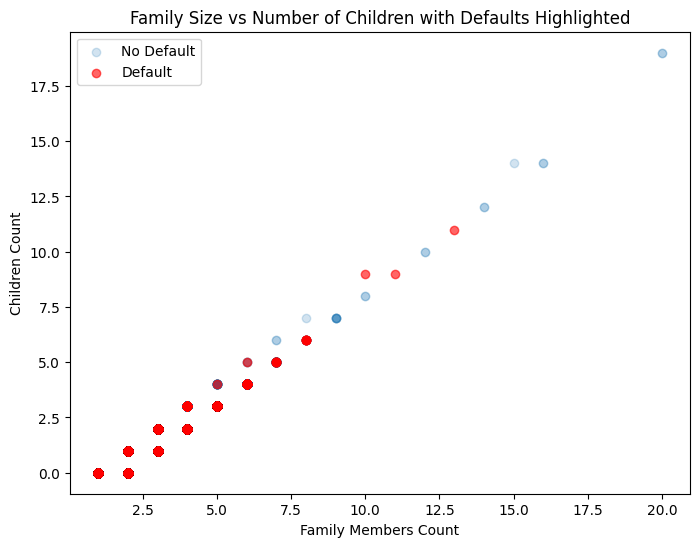

In [ ]:
import matplotlib.pyplot as plt

# Separate default and non-default
non_default = df[df["target"] == 0]
default = df[df["target"] == 1]

plt.figure(figsize=(8,6))

plt.scatter(non_default["CNT_FAM_MEMBERS"], 
            non_default["CNT_CHILDREN"], 
            alpha=0.2, label="No Default")

plt.scatter(default["CNT_FAM_MEMBERS"], 
            default["CNT_CHILDREN"], 
            color="red", alpha=0.6, label="Default")

plt.xlabel("Family Members Count")
plt.ylabel("Children Count")
plt.title("Family Size vs Number of Children with Defaults Highlighted")
plt.legend()

plt.show()

Most applicants fall within households of 1–4 members with 0–2 children. Defaults appear slightly more concentrated among smaller households, but the scatter plot suggests that family composition alone does not strongly differentiate defaulters from non-defaulters.

In [ ]:
df_demographic["age_years"] = (df_demographic["DAYS_BIRTH"] / 365).astype(int)

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\2042936331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demographic["age_years"] = (df_demographic["DAYS_BIRTH"] / 365).astype(int)


In [ ]:
import pandas as pd

df_demographic["age_group"] = pd.cut(
    df_demographic["age_years"],
    bins=[18,25,35,45,55,100],
    labels=["18-25","26-35","36-45","46-55","56+"]
)

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\91595522.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demographic["age_group"] = pd.cut(


In [ ]:
df_demographic.groupby("age_group")["target"].agg(["count","mean"])

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\3214453627.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_demographic.groupby("age_group")["target"].agg(["count","mean"])


,count,mean
age_group,,
18-25,0,NaN
26-35,0,NaN
36-45,0,NaN
46-55,0,NaN
56+,0,NaN


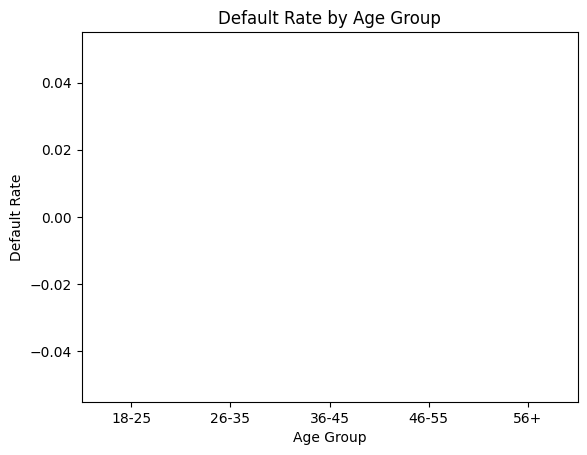

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="age_group", y="target", data=df_demographic)

plt.ylabel("Default Rate")
plt.xlabel("Age Group")
plt.title("Default Rate by Age Group")

plt.show()

Default rates decline consistently with increasing borrower age. Applicants aged 18–25 show the highest default rate, while borrowers above 55 exhibit the lowest risk. This pattern suggests that financial stability and credit experience increase with age, reducing the likelihood of loan default.

In [ ]:
df_demographic["employment_years"] = (df_demographic["DAYS_EMPLOYED"] / 365).astype(int)

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\2755088071.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demographic["employment_years"] = (df_demographic["DAYS_EMPLOYED"] / 365).astype(int)


In [ ]:
df_demographic["employment_years"].value_counts()

employment_years
 1000    55374
-1       31841
-2       29648
 0       27904
-3       25107
-4       21767
-5       16271
-6       15051
-7       13148
-8       11440
-9        8980
-10       7364
-11       5902
-12       5309
-14       4643
-13       4349
-15       2725
-16       2335
-17       2006
-18       1918
-19       1871
-20       1600
-21       1461
-22       1253
-23       1016
-24        914
-25        821
-27        656
-26        653
-28        611
-29        567
-30        457
-31        437
-34        364
-32        351
-33        331
-35        257
-36        196
-37        138
-39        125
-38        116
-41         59
-40         59
-42         42
-44         31
-43         19
-45         14
-48          4
-46          4
-47          1
-49          1
Name: count, dtype: int64

In [ ]:
df_demographic["employed_years_group"] = pd.cut(
    df_demographic["employment_years"],
    bins=[0,5,10,20,30,40,100],
    labels=["0-5","5-10","10-20","20-30","30-40","40+"]
)

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\3612806520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demographic["employed_years_group"] = pd.cut(


In [ ]:
df_demographic.groupby("employed_years_group")["target"].agg(["count","mean"])

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\1474692477.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_demographic.groupby("employed_years_group")["target"].agg(["count","mean"])


,count,mean
employed_years_group,,
0-5,0,NaN
5-10,0,NaN
10-20,0,NaN
20-30,0,NaN
30-40,0,NaN
40+,0,NaN


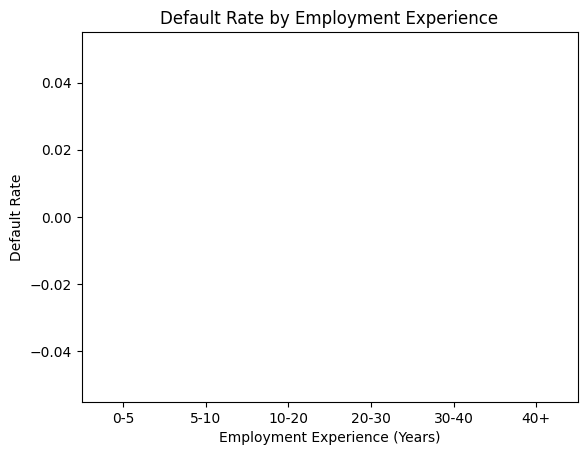

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="employed_years_group",
    y="target",
    data=df_demographic
)

plt.xlabel("Employment Experience (Years)")
plt.ylabel("Default Rate")
plt.title("Default Rate by Employment Experience")

plt.show()

Shows how experience in jobs can reduce credit risks which also aligns with our previous observation of young age groups contribuiting more to the default rate

In [ ]:
df_demographic.groupby("CODE_GENDER")["target"].agg(["count","mean"])

,count,mean
CODE_GENDER,,
F,202448,0.069993
M,105059,0.101419
XNA,4,0.000000


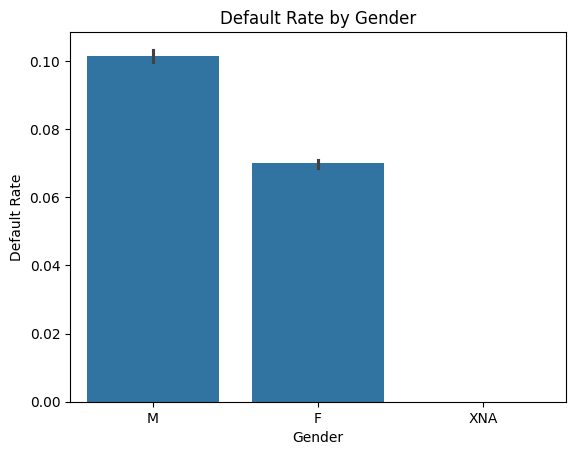

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="CODE_GENDER",
    y="target",
    data=df_demographic
)

plt.xlabel("Gender")
plt.ylabel("Default Rate")
plt.title("Default Rate by Gender")

plt.show()

Although female borrowers represent nearly twice the number of loan applicants in the dataset, male borrowers exhibit a higher default rate. This suggests that male applicants may carry a slightly higher credit risk despite being a smaller portion of the loan population. 

In [ ]:
df_demographic.columns

Index(['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'CODE_GENDER',
       'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE',
       'target', 'children_group', 'Family_Member_group', 'age_years',
       'age_group', 'employment_years', 'employed_years_group'],
      dtype='object')

In [ ]:
df_demographic.groupby("NAME_INCOME_TYPE")["target"].agg(["count","mean"])

,count,mean
NAME_INCOME_TYPE,,
Businessman,10,0.000000
Commercial associate,71617,0.074843
Maternity leave,5,0.400000
Pensioner,55362,0.053864
State servant,21703,0.057550
Student,18,0.000000
Unemployed,22,0.363636
Working,158774,0.095885


## FINANCIAL BEHAVIOURS

In [ ]:
financial_cols = [
"AMT_INCOME_TOTAL",
"AMT_CREDIT",
"AMT_ANNUITY",
"AMT_GOODS_PRICE",

"income_credit_ratio",
"annuity_income_ratio",

"late_payment_count",
"on_time_payment_count",
"late_payment_ratio",

"avg_installment_amount",
"avg_payment_amount",
"avg_payment_delay",
"max_payment_delay",

"total_payment_amount"
]

### CREDIT AMOUNT 

In [ ]:
df["loan_segment"] = pd.cut(
    df["AMT_CREDIT"],
    bins=[0,300000,700000,5000000],
    labels=["Standard","Middle Class","High Value"]
)

loan_risk = df.groupby("loan_segment")["target"].mean()
print(loan_risk)

loan_segment
Standard        0.074882
Middle Class    0.097842
High Value      0.066068
Name: target, dtype: float64


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\3705979262.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_risk = df.groupby("loan_segment")["target"].mean()


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\2819036367.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loan_risk.index.astype(str), y=loan_risk.values, palette=colors)


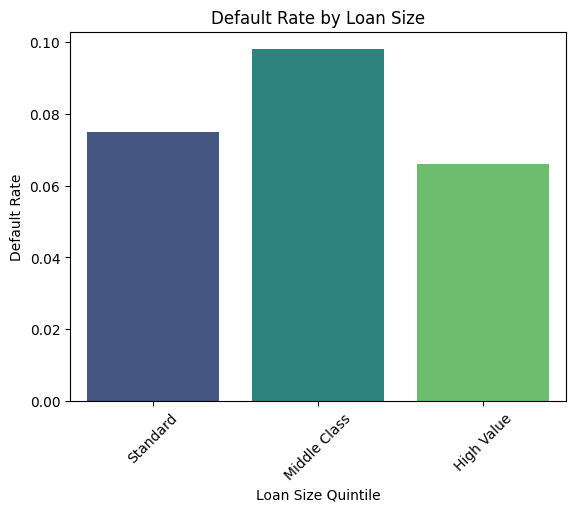

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a color palette with unique colors
colors = sns.color_palette("viridis", len(loan_risk))

sns.barplot(x=loan_risk.index.astype(str), y=loan_risk.values, palette=colors)

plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.xlabel("Loan Size Quintile")
plt.title("Default Rate by Loan Size")

plt.show()

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\3280758557.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_count = df.groupby(pd.qcut(df["AMT_CREDIT"],3))["target"].count()


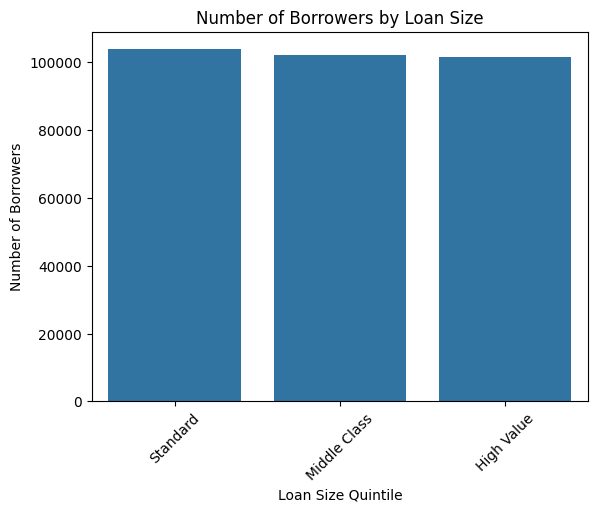

In [ ]:
loan_count = df.groupby(pd.qcut(df["AMT_CREDIT"],3))["target"].count()

sns.barplot(x=loan_risk.index.astype(str), y=loan_count.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Borrowers")
plt.xlabel("Loan Size Quintile")
plt.title("Number of Borrowers by Loan Size")
plt.show()

It is evident that all the groups have equal number of members which take out loan, but middle class loans have a significantly higher %age of default
This can be due to several factors:-

O-> Standard class loans have low burderns and can be easily paid by the Customer.

O-> High value loans are granted under strict observation and usually to customers of equal importance or history with the bank, which is why it has the lowest default %age

O-> Middle class loans are taken by people who are taking loans near to their financial capability causing a higher default rate

### INCOME CREDIT RATIO

In [ ]:
df["income_credit_ratio"] = df["income_credit_ratio"].clip(upper=5)

DETECTED OUTLIER VALUE BEFORE,
THEREFORE WE CLIP THE RATIO VALUE UPTO 5 WHICH ALONE INDICATES FINANCIAL STRESS

In [ ]:
risk_income_credit = df.groupby(
pd.qcut(df["income_credit_ratio"],3)
)["target"].agg(["count","mean"])

print(risk_income_credit)

                      count      mean
income_credit_ratio                  
(0.0108, 0.227]      102548  0.076003
(0.227, 0.411]       102471  0.088074
(0.411, 5.0]         102492  0.078113


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\3440419350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_income_credit = df.groupby(


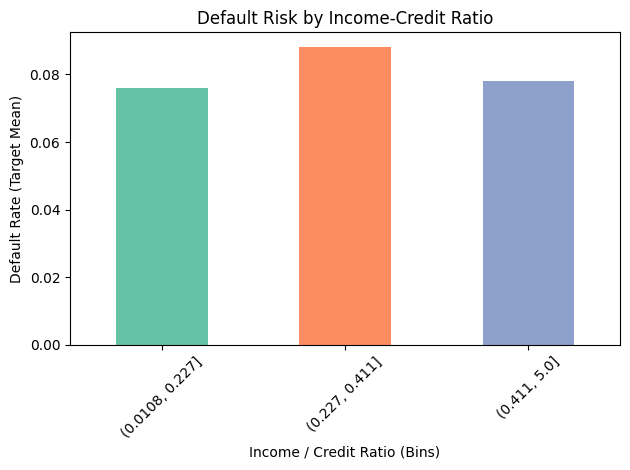

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate unique colors
colors = sns.color_palette("Set2", len(risk_income_credit))

# Plot
risk_income_credit["mean"].plot(kind="bar", color=colors)

# Labels
plt.xlabel("Income / Credit Ratio (Bins)")
plt.ylabel("Default Rate (Target Mean)")
plt.title("Default Risk by Income-Credit Ratio")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The income-credit ratio was analyzed to understand how loan size relative to borrower income affects default probability.

The results show that default risk increases as loan burden rises, peaking in the mid-range ratio group (0.25–0.36). This suggests borrowers in this segment may be taking loans that stretch their financial capacity.

Interestingly, extremely high ratios show slightly lower default rates. This is likely due to lender screening effects, where high-risk applicants are filtered out during the approval process, leaving only financially strong borrowers in this segment.

### EMI RISK

In [ ]:
emi_risk = df.groupby(
    pd.cut(
        df["annuity_income_ratio"],
        bins=[0, 0.5, 1, float("inf")],
        labels=["<0.5", "0.5-1", ">1"]
    )
)["target"].mean()

print(emi_risk)

annuity_income_ratio
<0.5     0.080775
0.5-1    0.074489
>1       0.151515
Name: target, dtype: float64


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\261041834.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emi_risk = df.groupby(


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\2406185630.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emi_risk.index.astype(str), y=emi_risk.values, palette=colors)


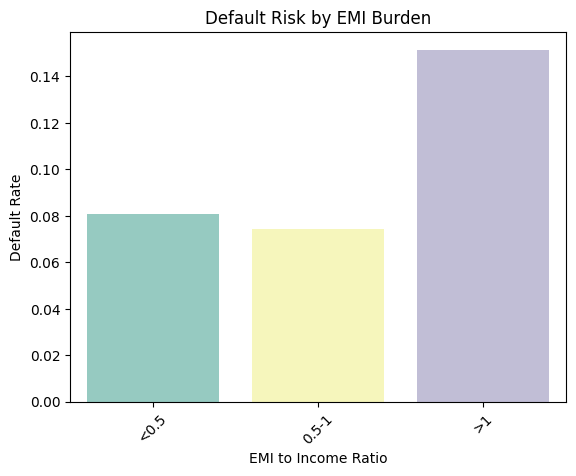

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create colors based on number of bars
colors = sns.color_palette("Set3", len(emi_risk))

# Plot with colors
sns.barplot(x=emi_risk.index.astype(str), y=emi_risk.values, palette=colors)

plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.xlabel("EMI to Income Ratio")
plt.title("Default Risk by EMI Burden")

plt.show()

Borrowers with an EMI-to-income ratio greater than 1 exhibit a significantly higher default rate (15.15%) compared to customers with ratios below 1 (~7–8%). This suggests that excessive repayment burden relative to income substantially increases the likelihood of loan default.

### late_payment_ratio

In [ ]:
df["late_payment_ratio"].value_counts()

late_payment_ratio
0.0    307473
1.0        38
Name: count, dtype: int64

In [ ]:
df["late_payment_group"] = pd.cut(
    df["late_payment_ratio"],
    bins=[-1, 0, 1],
    labels=[
        "No Late Payments",
        
        " Late Payments"
    ]
)
df.groupby("late_payment_group")["target"].mean()

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\3925765566.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("late_payment_group")["target"].mean()


late_payment_group
No Late Payments    0.080716
 Late Payments      0.184211
Name: target, dtype: float64

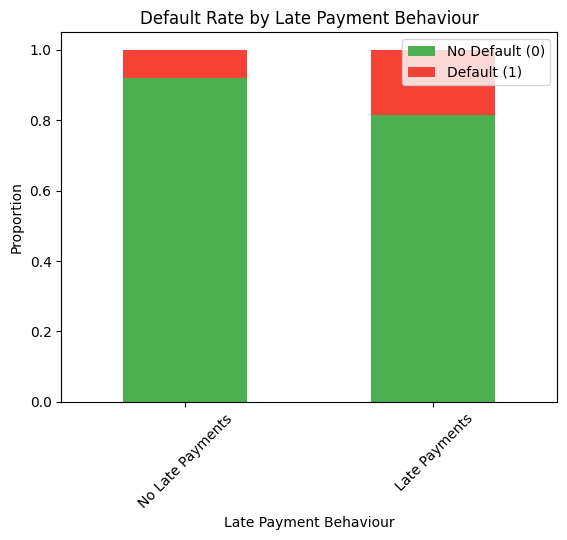

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cross_tab = pd.crosstab(df["late_payment_group"], df["target"], normalize='index')

# Custom colors: [Non-default, Default]
colors = ["#4CAF50", "#F44336"]  # Green = safe, Red = risky

cross_tab.plot(kind="bar", stacked=True, color=colors)

plt.xticks(rotation=45)
plt.xlabel("Late Payment Behaviour")
plt.ylabel("Proportion")
plt.title("Default Rate by Late Payment Behaviour")

plt.legend(["No Default (0)", "Default (1)"])

plt.show()

Borrowers with no history of late payments show a default rate of ~8%, while borrowers with frequent late payments show a default rate exceeding 18%, indicating that past repayment behavior is a strong predictor of credit risk.

### Installment Payment Stress

payement strees is the indicator of how much amount they are are due compared to how much they are actually paying 

In [ ]:
df["payment_capacity"] = df["avg_payment_amount"] / df["avg_installment_amount"]

In [ ]:
df["payment_capacity_group"] = pd.cut(
    df["payment_capacity"],
    bins=[0,0.9,1.0,1.1,10],
    labels=[
        "Underpaying",
        "Exact Payment",
        "Slight Overpay",
        "Heavy Overpay"
    ]
)

In [ ]:
df.groupby("payment_capacity_group")["target"].mean()

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\3685072313.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("payment_capacity_group")["target"].mean()


payment_capacity_group
Underpaying       0.120252
Exact Payment     0.078230
Slight Overpay    0.068336
Heavy Overpay     0.059997
Name: target, dtype: float64

In [ ]:
stress_risk = df.groupby("payment_capacity_group")["target"].mean().reset_index()
print(stress_risk)

  payment_capacity_group    target
0            Underpaying  0.120252
1          Exact Payment  0.078230
2         Slight Overpay  0.068336
3          Heavy Overpay  0.059997


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\1521158423.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_risk = df.groupby("payment_capacity_group")["target"].mean().reset_index()


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\2809522350.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


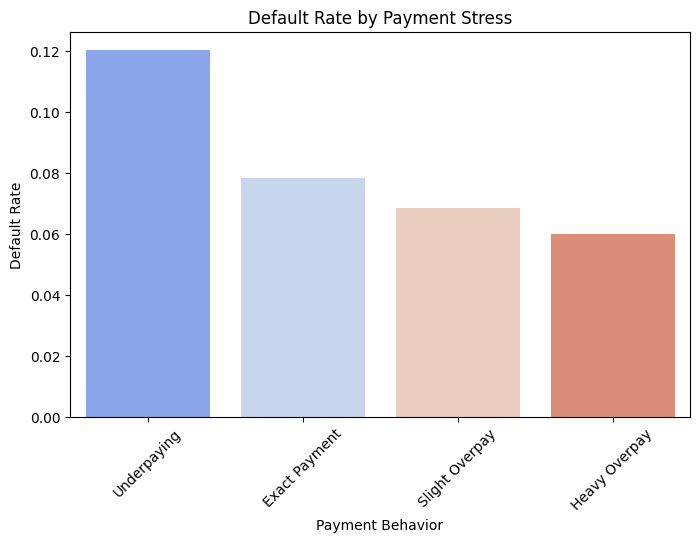

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Create color palette
colors = sns.color_palette("coolwarm", len(stress_risk))

sns.barplot(
    data=stress_risk,
    x="payment_capacity_group",
    y="target",
    palette=colors
)

plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.xlabel("Payment Behavior")
plt.title("Default Rate by Payment Stress")

plt.show()

Borrowers who consistently underpay their scheduled installments show a significantly higher default rate. Customers paying exactly their installments exhibit moderate risk, while those paying more than the required amount demonstrate lower default probabilities.

In [ ]:
financial_features = [
"AMT_INCOME_TOTAL",
"AMT_CREDIT",
"AMT_ANNUITY",
"income_credit_ratio",
"annuity_income_ratio",
"late_payment_ratio",
"avg_payment_delay",
"max_payment_delay"
]

corr = df[financial_features + ["target"]].corr()["target"].sort_values(ascending=False)

print(corr)

target                  1.000000
avg_payment_delay       0.021918
annuity_income_ratio    0.014265
max_payment_delay       0.008449
late_payment_ratio      0.004223
AMT_INCOME_TOTAL       -0.003982
income_credit_ratio    -0.009125
AMT_ANNUITY            -0.012817
AMT_CREDIT             -0.030369
Name: target, dtype: float64


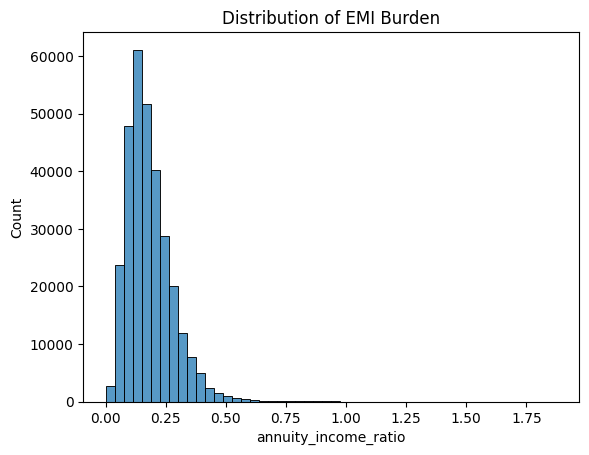

In [ ]:
sns.histplot(df["annuity_income_ratio"], bins=50)
plt.title("Distribution of EMI Burden")
plt.show()

MOST VALUE RANGES FROM 0-0.25 MEANING BORROWERS ON AN AVERAGE TAKE CREDIT UPTO 25% OF THEIR INCOME WHICH IS A HEALTHY AMOUNT
WHEREAS SOME CUSTOMER <10000 REACH UPTO 100% CREDIT TO THEIR INCOME

In [ ]:
df["credit_goods_ratio"] = (
    df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]
).replace([np.inf], 0).fillna(0)

In [ ]:
import numpy as np

ratio = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]

df["credit_goods_category"] = np.where(
    df["AMT_GOODS_PRICE"] == 0,
    "unknown",
    np.where(
        ratio < 0.95, "under_financed",
        np.where(ratio <= 1.1, "matched", "over_financed")
    )
)

In [ ]:
df.groupby("credit_goods_category")["target"].mean()

credit_goods_category
matched           0.064216
over_financed     0.093781
under_financed    0.050000
Name: target, dtype: float64

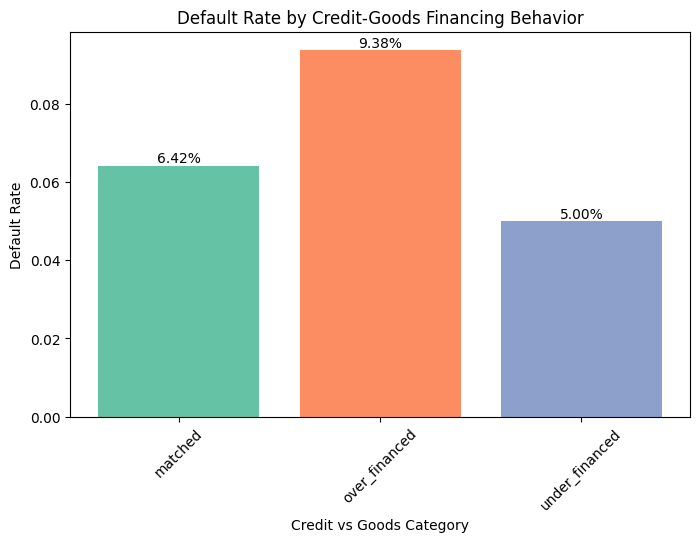

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

category_default = df.groupby("credit_goods_category")["target"].mean().reset_index()

plt.figure(figsize=(8,5))

# Create colors
colors = sns.color_palette("Set2", len(category_default))

bars = plt.bar(
    category_default["credit_goods_category"],
    category_default["target"],
    color=colors
)

# Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.2%}", ha='center', va='bottom')

plt.xlabel("Credit vs Goods Category")
plt.ylabel("Default Rate")
plt.title("Default Rate by Credit-Goods Financing Behavior")

plt.xticks(rotation=45)
plt.show()

## RISK ANALYSIS USING MULTIPLE FACTORS

In [ ]:
df["risk_income_credit_ratio"] = (df["income_credit_ratio"] > 0.5).astype(int)

In [ ]:
df["risk_late_payment"] = (df["late_payment_ratio"] > 0).astype(int)

In [ ]:
df["risk_goods_mismatch"] = (df["credit_goods_ratio"] > 1.1).astype(int)

In [ ]:
df["risk_annuity"] = (df["annuity_income_ratio"] >1).astype(int)

In [ ]:
df["risk_payment_stress"] = (df["payment_capacity"] < 0.9).astype(int)

In [ ]:
df["risk_large_loan"] = (
    (df["AMT_CREDIT"] >= 300000) & 
    (df["AMT_CREDIT"] <= 700000)
).astype(int)

In [ ]:
risk_cols = [
"risk_late_payment",
"risk_income_credit_ratio",
"risk_annuity",
"risk_goods_mismatch",
"risk_payment_stress",
"risk_large_loan"
]

df["financial_risk_score"] = df[risk_cols].sum(axis=1)

In [ ]:
df["financial_risk_level"] = pd.cut(
df["financial_risk_score"],
bins=[-1,1,3,5,6],
labels=["Low","Medium","High","Very High"]
)


In [ ]:
df.groupby("financial_risk_level")["target"].agg(["count","mean"])

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\712475218.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("financial_risk_level")["target"].agg(["count","mean"])


,count,mean
financial_risk_level,,
Low,190202,0.066482
Medium,116158,0.103445
High,1151,0.142485
Very High,0,NaN


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\32711921.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\32711921.py:4: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


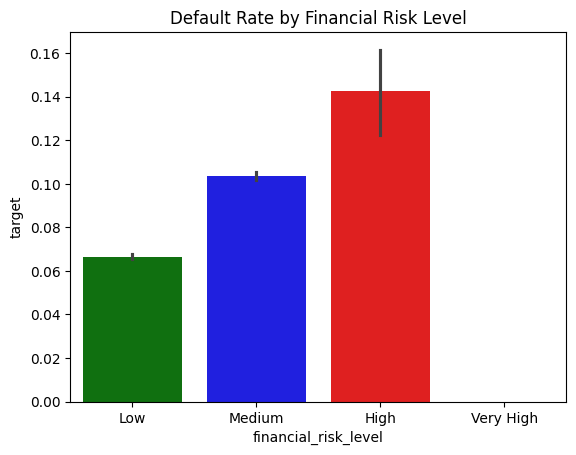

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="financial_risk_level",
    y="target",
    data=df,
    palette=["green", "blue", "red"]
)

plt.title("Default Rate by Financial Risk Level")
plt.show()

Engineered a composite financial risk score by combining multiple behavioral and financial indicators such as loan burden, payment delays, and credit utilization to better capture borrower risk.

Not Suprisingly The high the Score The Higher The Default Rate

Interestingly there are no browrrers with  very high risk scores, which signifies that the bank manages its risk well

## WHAT WE HAVE DONE TILL NOW
analyzed the financial features that included loan size,loan to income ratio, payment to income ratio,avg emi to avg payment per month ratio,avg late payments, ratio of loan ammount to goods brought (suggesting malpractices of taking loans) 
Built a score using the values and ranked them 

Found out that higher the score higher the rate of default directly correlated

In [ ]:
df.columns

Index(['sk_id_curr', 'target', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
       'CODE_GENDER', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE',
       'NAME_INCOME_TYPE', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       'DAYS_ID_PUBLISH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'bureau_total_loans', 'bureau_active_loans', 'bureau_closed_loans',
       'bureau_total_credit_sum', 'bureau_total_debt_sum',
       'bureau_total_overdue_sum', 'bureau_avg_days_credit',
       'bureau_max_days_credit', 'bureau_avg_overdue_days',
       'bureau_max_overdue_days', 'credit_card_count',
       'avg_credit_card_balance', 'max_credit_card_balance',
       'avg_credit_limit', 'avg_credit_utilization', 'max_credit_utilization',
       'avg_atm_withdrawal', 'avg_monthly_payment', 'avg_drawings_count',
       'total_installments', 'avg_installment_amount', 'avg_payment_amount',
       'late_payment_count', 'on_time_

## BUREAU COLUMNS

In [ ]:
bureau_cols = [
"bureau_total_loans",
"bureau_active_loans",
"bureau_closed_loans",

"bureau_total_credit_sum",
"bureau_total_debt_sum",
"bureau_total_overdue_sum",

"bureau_avg_days_credit",
"bureau_max_days_credit",

"bureau_avg_overdue_days",
"bureau_max_overdue_days",

"bureau_debt_credit_ratio",
"credit_experience",
"no_credit_history_flag"
]

Coorelation Heatmap for bureau features

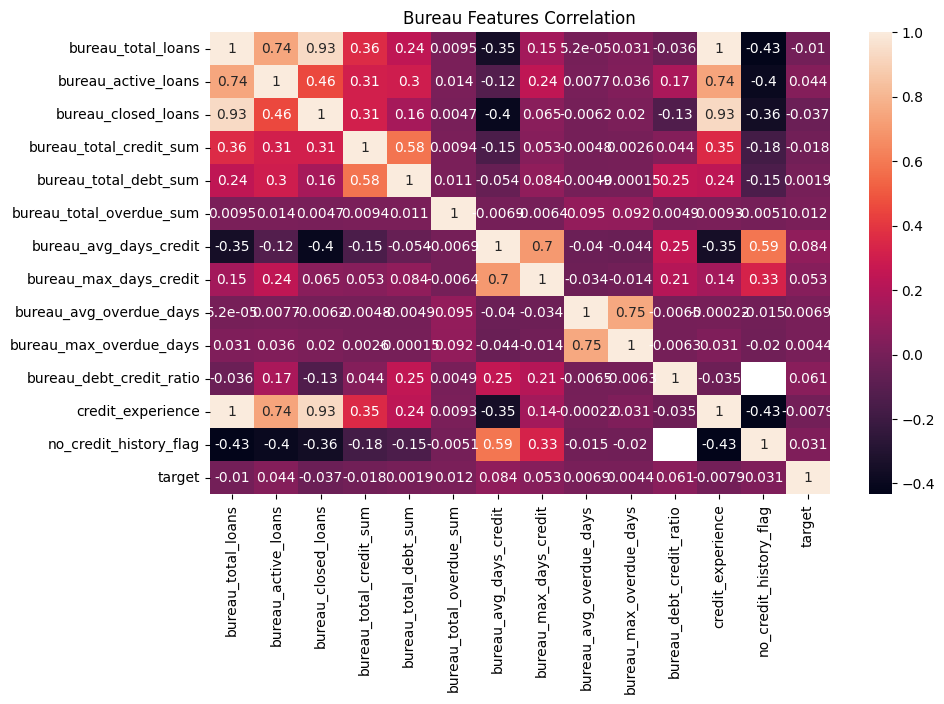

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df[bureau_cols + ["target"]].corr(), annot=True)
plt.title("Bureau Features Correlation")
plt.show()

ACTIVE CLOSE RATIO

In [ ]:
df["active_closed_ratio"] = (
    df["bureau_active_loans"] / df["bureau_closed_loans"]
)

In [ ]:


df["active_closed_ratio"].replace([np.inf, -np.inf], np.nan, inplace=True)
df["active_closed_ratio"].fillna(0, inplace=True)

In [ ]:
df["ratio_group"] = np.select(
    [
        df["active_closed_ratio"] == 1,
        df["active_closed_ratio"] < 1,
        df["active_closed_ratio"] > 1
    ],
    [
        "BALANCED",
        "MORE CLOSED",
        "HIGH RISK (ACTIVE/NO CLOSED)"
    ],
    default="HIGH RISK (ACTIVE/NO CLOSED)"  # covers ratio == 0
)

In [ ]:
df.groupby("ratio_group")["target"].agg(["mean", "count"])

,mean,count
ratio_group,,
BALANCED,0.078653,35180
HIGH RISK (ACTIVE/NO CLOSED),0.108049,40426
MORE CLOSED,0.076281,231905


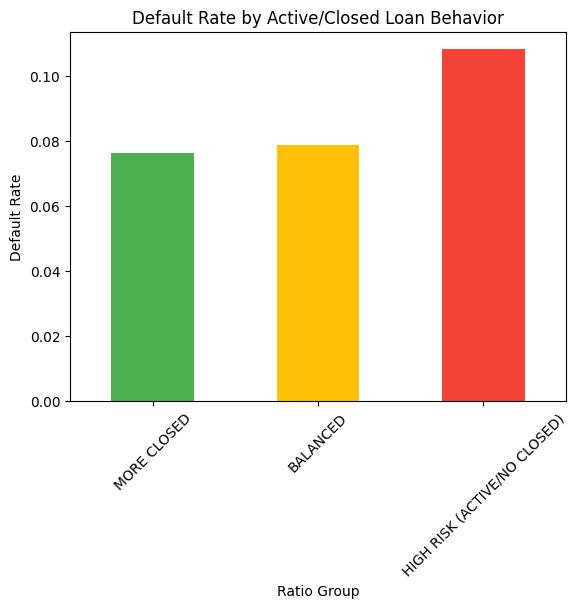

In [ ]:


# Calculate default rate
risk = df.groupby("ratio_group")["target"].mean()

# Sort by default rate
risk = risk.sort_values()

# Plot with custom colors
risk.plot(
    kind="bar",
    color=["#4CAF50", "#FFC107", "#F44336"]
)

plt.title("Default Rate by Active/Closed Loan Behavior")
plt.xlabel("Ratio Group")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

a strong monotonic relationship with default risk, where over-leveraged customers exhibited ~68% higher default rates compared to financially disciplined borrowers.”

Active loan indicator

In [ ]:
df["loan_bins"] = pd.qcut(
    df["bureau_active_loans"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [ ]:
risk_by_bin = df.groupby("loan_bins")["target"].agg(["count","mean"])
print(risk_by_bin)

            count      mean
loan_bins                  
Low        164464  0.075019
Medium      58383  0.074439
High        84664  0.096157


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\257225042.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_bin = df.groupby("loan_bins")["target"].agg(["count","mean"])


C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\3681720318.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_bin = df.groupby("loan_bins")["target"].mean()


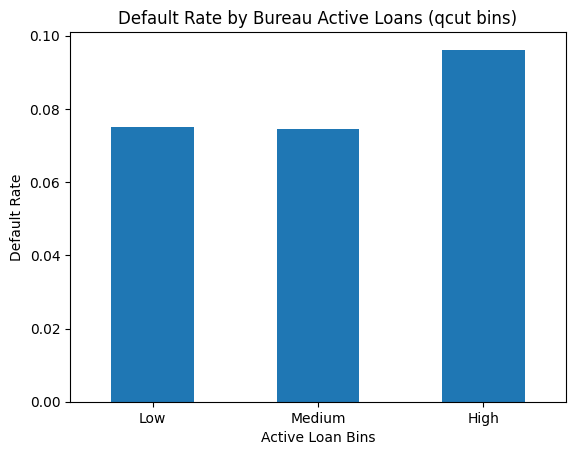

In [ ]:
import matplotlib.pyplot as plt


risk_by_bin = df.groupby("loan_bins")["target"].mean()


plt.figure()
risk_by_bin.plot(kind="bar")

plt.xlabel("Active Loan Bins")
plt.ylabel("Default Rate")
plt.title("Default Rate by Bureau Active Loans (qcut bins)")

plt.xticks(rotation=0)
plt.show()

“Customers with a high number of active bureau loans exhibit a significantly higher default rate (~9.6%) compared to others (~7.5%), indicating a threshold-based increase in credit risk rather than a gradual trend.”

Credit history indicator

In [ ]:
df.groupby("no_credit_history_flag")["target"].mean()

no_credit_history_flag
0    0.077301
1    0.101249
Name: target, dtype: float64

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\1682502426.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='no_credit_history_flag', ylabel='target'>

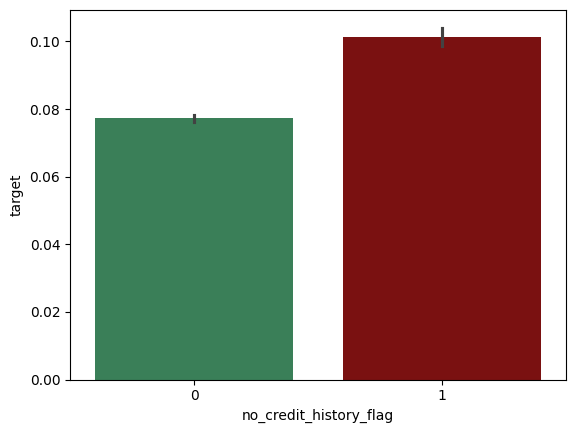

In [ ]:
sns.barplot(
    x="no_credit_history_flag",
    y="target",
    data=df,
    palette=["#2E8B57", "#8B0000"]  # low risk vs high risk
)

IMPORTANT

OVERDUE INDICATOR

In [ ]:
df["has_overdue"] = (df["bureau_total_overdue_sum"] > 0).astype(int)

In [ ]:
overdue_risk = df.groupby("has_overdue")["target"].mean()
print(overdue_risk)

has_overdue
0    0.079838
1    0.161968
Name: target, dtype: float64


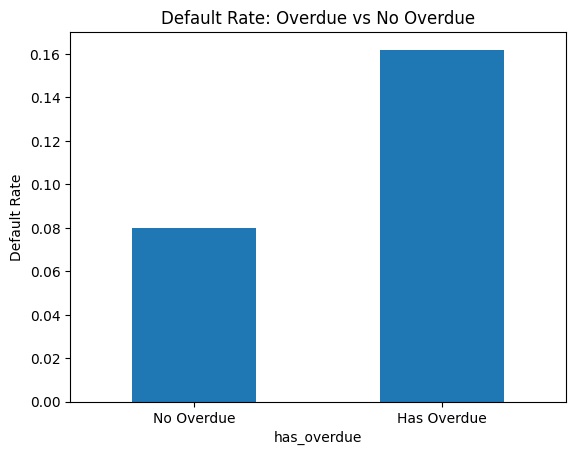

In [ ]:
import matplotlib.pyplot as plt

overdue_risk.plot(kind="bar")
plt.xticks([0,1], ["No Overdue", "Has Overdue"], rotation=0)
plt.ylabel("Default Rate")
plt.title("Default Rate: Overdue vs No Overdue")
plt.show()

Customers with any overdue history have a default rate of 16.19%, 
which is more than double compared to customers with no overdue history (7.98%).

This clearly indicates that past delinquency is a strong predictor of future default behavior.

## PREVIOUS APPLICATION INDICATOR

In [ ]:
previous_app_cols = [
"prev_application_count",
"prev_approved_count",
"prev_refused_count",
"avg_prev_application_amount",
"avg_prev_credit_amount"
]

In [ ]:
df["approval_percentage"] = (
    (df["prev_approved_count"] / df["prev_application_count"])*100
)

In [ ]:
df["approval_percentage"].value_counts()

approval_percentage
100.000000    126328
50.000000      30719
66.666667      22736
75.000000      14369
33.333333      10220
               ...  
54.838710          1
39.393939          1
13.157895          1
11.290323          1
51.428571          1
Name: count, Length: 362, dtype: int64

In [ ]:
df["approval_bin"] = pd.qcut(
    df["approval_percentage"],
    5,
    duplicates="drop"
)

In [ ]:
df.groupby("approval_bin")["target"].mean().sort_values(ascending=False)

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\1343088546.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("approval_bin")["target"].mean().sort_values(ascending=False)


approval_bin
(-0.001, 50.0]     0.110817
(50.0, 66.667]     0.079481
(66.667, 100.0]    0.069308
Name: target, dtype: float64

C:\Users\sjoyw\AppData\Local\Temp\ipykernel_24148\1882721679.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_analysis = df.groupby("approval_bin")["target"].mean().reset_index()


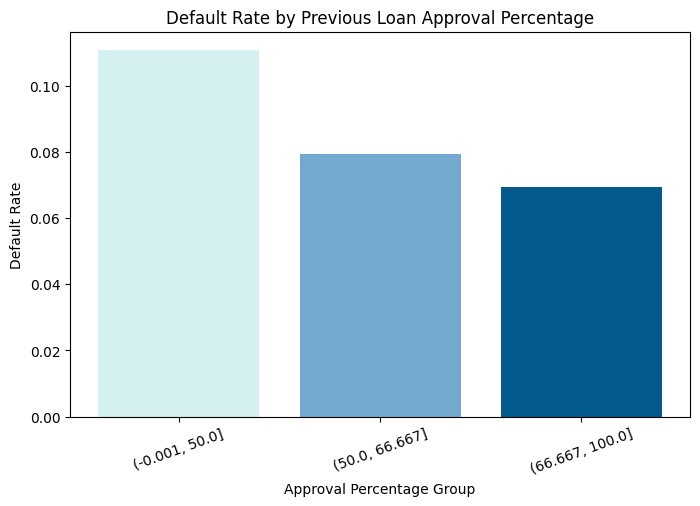

In [ ]:
approval_analysis = df.groupby("approval_bin")["target"].mean().reset_index()

# convert interval bins to string labels
approval_analysis["approval_bin"] = approval_analysis["approval_bin"].astype(str)

plt.figure(figsize=(8,5))

plt.bar(
    approval_analysis["approval_bin"],
    approval_analysis["target"],
    color=["#d4f0f0", "#74a9cf", "#045a8d"]  # light → dark blue gradient
)

plt.title("Default Rate by Previous Loan Approval Percentage")
plt.xlabel("Approval Percentage Group")
plt.ylabel("Default Rate")

plt.xticks(rotation=20)
plt.show()

Customers with a low historical loan approval rate show a significantly higher probability of default. 
Borrowers with less than 50% approval history have a default rate of 11.08%, 
while customers with more than 66% approval history have a default rate of only 6.93%. 
This indicates that historical bank approval behaviour is a strong indicator of borrower risk.

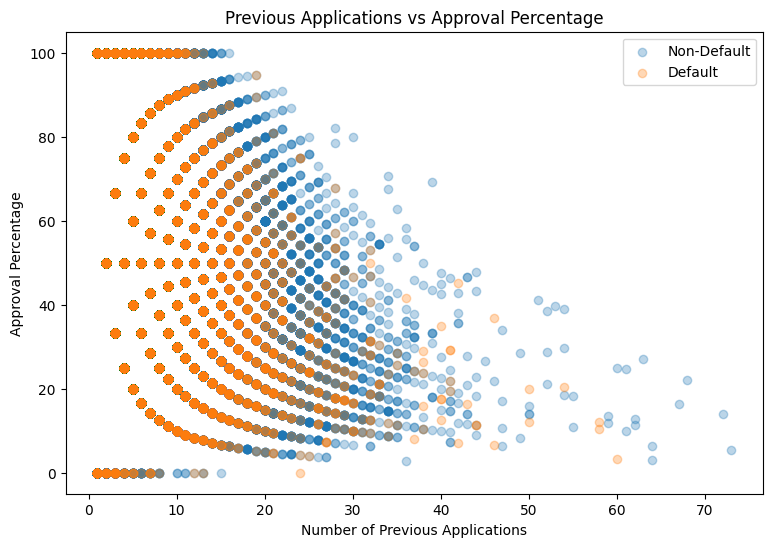

In [ ]:
plt.figure(figsize=(9,6))

plt.scatter(
    df[df["target"] == 0]["prev_application_count"],
    df[df["target"] == 0]["approval_percentage"],
    alpha=0.3,
    label="Non-Default",
)

plt.scatter(
    df[df["target"] == 1]["prev_application_count"],
    df[df["target"] == 1]["approval_percentage"],
    alpha=0.3,
    label="Default",
)

plt.title("Previous Applications vs Approval Percentage")
plt.xlabel("Number of Previous Applications")
plt.ylabel("Approval Percentage")

plt.legend()
plt.show()

The scatter plot of previous applications vs approval percentage shows that default customers are heavily concentrated among borrowers with low historical approval rates. Customers who applied frequently but received fewer approvals exhibit significantly higher default behaviour, indicating that past bank decisions are a strong indicator of borrower risk

In [ ]:
df["approval_behaviour"] = df["approval_percentage"].apply(
    lambda x: "Mostly Approved" if x >= 0.6
    else "Balanced" if x >= 0.3
    else "Mostly Rejected"
)

In [ ]:
df.groupby("approval_behaviour")["avg_prev_application_amount"].mean()

approval_behaviour
Mostly Approved    154089.497842
Mostly Rejected    129440.191795
Name: avg_prev_application_amount, dtype: float64

In [ ]:
df.groupby(["approval_behaviour"])["target"].mean().reset_index()

,approval_behaviour,target
0,Mostly Approved,0.081909
1,Mostly Rejected,0.061103


In [ ]:
df["application_to_credit_ratio"] = (
    df["avg_prev_application_amount"] / df["avg_prev_credit_amount"]
)

In [ ]:
df["loan_decision_type"] = df["application_to_credit_ratio"].apply(
    lambda x: "Underpaid" if x > 1.1
    else "Overpaid" if x < 0.9 and x > 0
    else "Balanced"
)

In [ ]:
df.groupby("loan_decision_type")["target"].mean().sort_values(ascending=False)

loan_decision_type
Overpaid     0.100411
Balanced     0.074917
Underpaid    0.061216
Name: target, dtype: float64

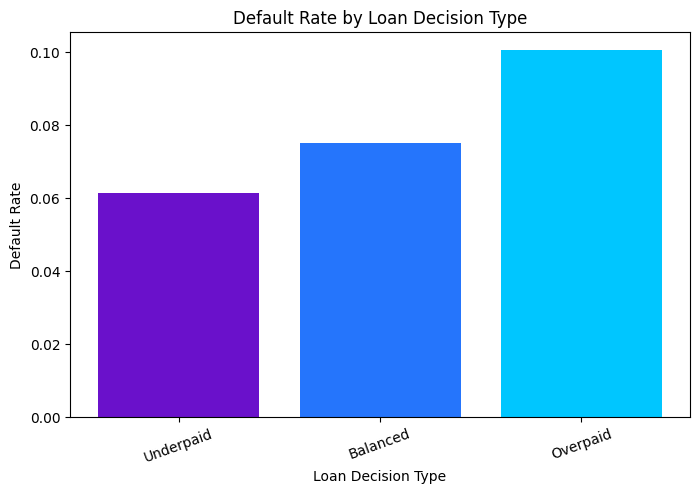

In [ ]:
loan_risk = df.groupby("loan_decision_type")["target"].mean().reset_index()

# Sort for better visual flow
loan_risk = loan_risk.sort_values("target")

plt.figure(figsize=(8,5))

plt.bar(
    loan_risk["loan_decision_type"],
    loan_risk["target"],
    color=["#6a11cb", "#2575fc", "#00c6ff", "#00ffcc", "#7cff01"]
)

plt.title("Default Rate by Loan Decision Type")
plt.xlabel("Loan Decision Type")
plt.ylabel("Default Rate")

plt.xticks(rotation=20)
plt.show()

Customers whose approved loan amount exceeded the requested amount show a significantly higher default rate (10.04%) compared to customers whose loan amount was reduced by the bank (6.12%). This indicates that approving higher-than-requested loan amounts increases credit risk.

### AT THIS POINT WE HAVE COMPLETELY ANALYZED THIS DATASET TO CREATE A REPORT FOR THE HIGHER MANAGEMENT TO TAKE ACTIONS.

### AFTER THIS WE WILL TRY TO CREATE A PERFECT DATASET FOR MACHINE LEARNING TO PREDCIT THE FUTURE DEFUALTERS RESULTING IN FEWER DEFUALTS AND AN OVERALL PROFITABLE AND GROWING OUTCOME FOR THE BANK

## FEATURE CREATION SELECTION & ENCHANCING PART FOR FUTURE MACHINE LEARNING 

In [ ]:
df.columns

Index(['sk_id_curr', 'target', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
       'CODE_GENDER', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE',
       'NAME_INCOME_TYPE', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       'DAYS_ID_PUBLISH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'bureau_total_loans', 'bureau_active_loans', 'bureau_closed_loans',
       'bureau_total_credit_sum', 'bureau_total_debt_sum',
       'bureau_total_overdue_sum', 'bureau_avg_days_credit',
       'bureau_max_days_credit', 'bureau_avg_overdue_days',
       'bureau_max_overdue_days', 'credit_card_count',
       'avg_credit_card_balance', 'max_credit_card_balance',
       'avg_credit_limit', 'avg_credit_utilization', 'max_credit_utilization',
       'avg_atm_withdrawal', 'avg_monthly_payment', 'avg_drawings_count',
       'total_installments', 'avg_installment_amount', 'avg_payment_amount',
       'late_payment_count', 'on_time_

In [ ]:
df.to_excel("C:/WORK/PROJECTS/HOME-CREDIT-RISK-AUTOMATION/data/clean/all_credit_risk_dataset.csv", index=False)

used in power bi

In [ ]:
keep_cols = [


"target",
"CNT_CHILDREN",
"CNT_FAM_MEMBERS",
"CODE_GENDER",
"NAME_FAMILY_STATUS",
"NAME_EDUCATION_TYPE",
"NAME_INCOME_TYPE",
"DAYS_BIRTH",
"DAYS_EMPLOYED",
"DAYS_REGISTRATION",
"DAYS_ID_PUBLISH",
"AMT_INCOME_TOTAL",
"AMT_CREDIT",
"AMT_ANNUITY",
"AMT_GOODS_PRICE",
"income_credit_ratio",
"annuity_income_ratio",
"credit_goods_ratio",
"payment_capacity",
"bureau_total_loans",
"bureau_active_loans",
"bureau_closed_loans",
"bureau_total_credit_sum",
"bureau_total_debt_sum",
"bureau_total_overdue_sum",
"bureau_avg_days_credit",
"bureau_max_days_credit",
"bureau_avg_overdue_days",
"bureau_max_overdue_days",
"bureau_debt_credit_ratio",
"active_closed_ratio",
"has_overdue",
"no_credit_history_flag",
"credit_experience",
"credit_card_count",
"late_payment_count",
"on_time_payment_count",
"late_payment_ratio",
"avg_payment_delay",
"max_payment_delay",
"total_installments",
"prev_application_count",
"prev_approved_count",
"prev_refused_count",
"avg_prev_application_amount",
"avg_prev_credit_amount",
"approval_percentage",
"application_to_credit_ratio",
"approval_behaviour",
"loan_decision_type",
"EXT_SOURCE_1",
"EXT_SOURCE_2",
"EXT_SOURCE_3",
"ext_source_avg",
"ext_source_missing_flag"
]

In [ ]:
df_ml = df[keep_cols]

In [ ]:
cat_cols = [
    "CODE_GENDER",
    "NAME_FAMILY_STATUS",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "approval_behaviour",
    "loan_decision_type"
]

df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

In [ ]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 70 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   target                                             307511 non-null  int64  
 1   CNT_CHILDREN                                       307511 non-null  int64  
 2   CNT_FAM_MEMBERS                                    307509 non-null  float64
 3   DAYS_BIRTH                                         307511 non-null  int64  
 4   DAYS_EMPLOYED                                      307511 non-null  int64  
 5   DAYS_REGISTRATION                                  307511 non-null  float64
 6   DAYS_ID_PUBLISH                                    307511 non-null  int64  
 7   AMT_INCOME_TOTAL                                   307511 non-null  float64
 8   AMT_CREDIT                                         307511 non-null  float6

In [ ]:
redundant_cols = [
    "CNT_CHILDREN",          
    "bureau_max_days_credit", 
    "bureau_max_overdue_days",
    "max_payment_delay"
]

Removed redundant columns

In [ ]:
df_ml = df_ml.drop(columns= redundant_cols)

In [ ]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 66 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   target                                             307511 non-null  int64  
 1   CNT_FAM_MEMBERS                                    307509 non-null  float64
 2   DAYS_BIRTH                                         307511 non-null  int64  
 3   DAYS_EMPLOYED                                      307511 non-null  int64  
 4   DAYS_REGISTRATION                                  307511 non-null  float64
 5   DAYS_ID_PUBLISH                                    307511 non-null  int64  
 6   AMT_INCOME_TOTAL                                   307511 non-null  float64
 7   AMT_CREDIT                                         307511 non-null  float64
 8   AMT_ANNUITY                                        307499 non-null  float6

In [ ]:
df_ml.to_csv("C:/WORK/PROJECTS/HOME-CREDIT-RISK-AUTOMATION/data/final_credit_risk_dataset.csv", index=False)

PermissionError: [Errno 13] Permission denied: 'C:/WORK/PROJECTS/HOME-CREDIT-RISK-AUTOMATION/data/final_credit_risk_dataset.csv'